In [11]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import math
import random

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device.type} device")

# Reproducibility
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)

torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True


Using cuda device


In [13]:
def generate_sine_data(num_points=2000):
    x = np.arange(num_points)
    data = np.sin(0.02 * x) + 0.1 * np.random.randn(num_points)
    data = (data - data.mean()) / data.std()   # normalize
    return torch.tensor(data, dtype=torch.float32)

In [14]:
sequence_length = 20
batch_size = 64

data = generate_sine_data()
train_size = int(0.8 * len(data))

train_data = data[:train_size]
test_data  = data[train_size:]

In [15]:
class TimeSeriesDataset(Dataset):
    def __init__(self, data, seq_length):
        self.data = data
        self.seq_length = seq_length

    def __len__(self):
        return len(self.data) - self.seq_length

    def __getitem__(self, idx):
        x = self.data[idx:idx+self.seq_length]
        y = self.data[idx+self.seq_length]
        return x.unsqueeze(-1), y.unsqueeze(-1)


In [16]:
train_dataset = TimeSeriesDataset(train_data, sequence_length)
test_dataset  = TimeSeriesDataset(test_data, sequence_length)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [17]:
class LSTM_Model(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        out, (h_n, c_n) = self.lstm(x)
        last_hidden = h_n[-1]          # (batch, hidden)
        out = self.fc(last_hidden)     # (batch, 1)
        return out


In [22]:
def regression_accuracy(preds, targets, epsilon=0.1):
    """
    preds, targets: shape (batch, 1)
    """
    correct = torch.abs(preds - targets) <= epsilon
    return correct.float().mean().item()

In [28]:
def train(dataloader, model, loss_fn, optimizer, device):
    model.train()
    total_loss = 0.0

    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        preds = model(X)
        loss = loss_fn(preds, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if batch % 100 == 0:
            print(f"loss: {loss.item():.6f}  [{batch * len(X)}/{len(dataloader.dataset)}]")

    avg_loss = total_loss / len(dataloader)
    return avg_loss

In [29]:
def test(dataloader, model, loss_fn, device):
    model.eval()
    test_loss = 0.0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            preds = model(X)
            loss = loss_fn(preds, y)
            test_loss += loss.item()

    avg_loss = test_loss / len(dataloader)
    print(f"Test Avg loss: {avg_loss:.6f}")
    return avg_loss

In [30]:
epochs = 40
lr = 3e-4

model = LSTM_Model().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
loss_fn = nn.MSELoss()

train_losses = []
test_losses = []
best_loss = float("inf")

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}\n-------------------------------")
    tr_loss = train(train_loader, model, loss_fn, optimizer, device)
    te_loss = test(test_loader, model, loss_fn, device)

    train_losses.append(tr_loss)
    test_losses.append(te_loss)

    if te_loss < best_loss:
        best_loss = te_loss
        torch.save(model.state_dict(), "LSTM_sequence.pth")

print("Done!")



Epoch 1
-------------------------------
loss: 0.957868  [0/1580]
Test Avg loss: 1.010717

Epoch 2
-------------------------------
loss: 0.947727  [0/1580]
Test Avg loss: 0.763347

Epoch 3
-------------------------------
loss: 0.568734  [0/1580]
Test Avg loss: 0.196587

Epoch 4
-------------------------------
loss: 0.150255  [0/1580]
Test Avg loss: 0.066621

Epoch 5
-------------------------------
loss: 0.060483  [0/1580]
Test Avg loss: 0.053750

Epoch 6
-------------------------------
loss: 0.064144  [0/1580]
Test Avg loss: 0.047836

Epoch 7
-------------------------------
loss: 0.061213  [0/1580]
Test Avg loss: 0.041581

Epoch 8
-------------------------------
loss: 0.043914  [0/1580]
Test Avg loss: 0.039567

Epoch 9
-------------------------------
loss: 0.047949  [0/1580]
Test Avg loss: 0.037397

Epoch 10
-------------------------------
loss: 0.050720  [0/1580]
Test Avg loss: 0.036639

Epoch 11
-------------------------------
loss: 0.045721  [0/1580]
Test Avg loss: 0.035054

Epoch 1

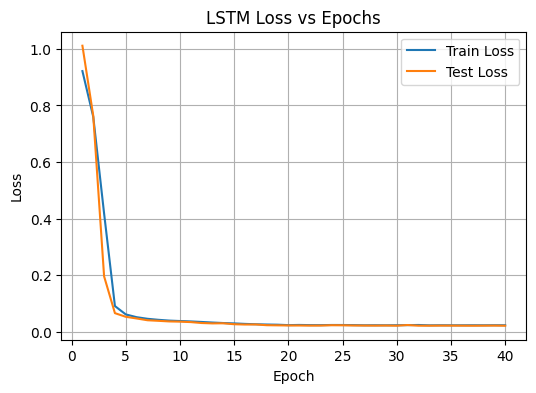

In [31]:
from matplotlib import pyplot as plt

epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(6,4))
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()
